# MESA 睡眠分期数据处理管线 — 教学演示

本 Notebook 以**单个被试**为例，逐步展示从原始数据到最终特征表的完整处理流程。

### 管线总览
```
原始EDF (ECG + 呼吸) ──→ Step 1: EDR特征提取    ──┐
原始EDF (ECG + 呼吸) ──→ Step 2: RRV特征提取    ──┤
原始体动 + PSG标注      ──→ Step 3: 数据预处理     ──┤
                              Step 4: 体动特征提取  ──┤
                              Step 5: HRV特征提取   ──┤
                              Step 6: 特征合并      ──→ 最终特征表 (460维)
```

### 特征维度
| 模态 | 特征数 | 说明 |
|---|---|---|
| ACT (体动) | 370 | 20个窗口大小 × 18种统计量 + 2个变换量 |
| HRV (心率变异性) | 29 | 时域 + 频域 + 非线性 + 几何 |
| RRV (呼吸率变异性) | ~62 | 5/7/9分钟滑动窗口 |
| EDR (ECG衍生呼吸) | ~62 | 同RRV，从ECG推导 |
| **合计** | **~460** | |

## 0. 环境准备

In [44]:
# ===================================================================
# 基础依赖
# ===================================================================
import sys
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 忽略不影响结果的警告
warnings.filterwarnings('ignore')

# ===================================================================
# 项目路径设置
# ===================================================================
# 把 sleep_analysis 项目加入 sys.path，让 import 能找到项目模块
PROJECT_ROOT = Path('/home/rdwang/repo/SleepStaging/third_party/sleep_analysis')
sys.path.insert(0, str(PROJECT_ROOT))

# ===================================================================
# 输出目录 (所有处理后的数据保存在这里)
# ===================================================================
OUTPUT_DIR = Path('/home/rdwang/repo/SleepStaging/temp/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 为输出目录创建子目录结构
for subdir in ['actigraph_data_clean', 'ecg_data_clean',
               'respiration_features_raw', 'edr_respiration_features_raw',
               'actigraph_features', 'hrv_features', 'features_full_combined']:
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

# ===================================================================
# 加载项目配置 (study_data.json 中的路径)
# ===================================================================
with open(PROJECT_ROOT / 'study_data.json') as f:
    cfg = json.load(f)

MESA_PATH = Path(cfg['mesa_path'])           # MESA 原始数据根目录
EDF_PATH = Path(cfg['mesa_path_edf'])        # EDF 文件目录
PROCESSED_PATH = Path(cfg['processed_mesa_path'])  # 全量处理数据目录

print(f'MESA 原始数据: {MESA_PATH}')
print(f'EDF 文件目录:   {EDF_PATH}')
print(f'教程输出目录:   {OUTPUT_DIR}')
print(f'Python 版本:    {sys.version.split()[0]}')

MESA 原始数据: /srv/shared/psgdata/mesa
EDF 文件目录:   /srv/shared/psgdata/mesa/polysomnography/edfs
教程输出目录:   /home/rdwang/repo/SleepStaging/temp/processed
Python 版本:    3.10.20


## 选择被试

MESA 数据集中每个被试有唯一 4 位 ID。从 EDF 文件列表中选一个来分析。

In [45]:
# ===================================================================
# 列出可用的被试
# ===================================================================
all_edfs = sorted(EDF_PATH.glob('*.edf'))
print(f'共 {len(all_edfs)} 个 EDF 文件')

# 提取前20个被试 ID 作为示例
sample_ids = []
for edf in all_edfs[:20]:
    m = re.findall(r'(\d{4})', edf.name)
    if m:
        sample_ids.append(m[0])
print(f'前20个可用被试: {sample_ids}')

# ===================================================================
# ★ 在这里指定要分析的被试 ID ★
# ===================================================================
SUBJ_ID = '0001'   # ← 改成你想看的被试编号
SUBJ_INT = int(SUBJ_ID)
print(f'\n当前选择: 被试 {SUBJ_ID}')

共 2055 个 EDF 文件
前20个可用被试: ['0001', '0002', '0006', '0010', '0012', '0014', '0016', '0021', '0027', '0028', '0033', '0035', '0036', '0038', '0046', '0048', '0050', '0052', '0054', '0056']

当前选择: 被试 0001


## 1. 原始数据加载

一名被试的原始数据包含四个部分：

| 数据 | 来源 | 说明 |
|---|---|---|
| 体动 (Actigraphy) | CSV | 腕带设备采集，7天 × 30秒/epoch = ~20000+ epochs |
| ECG R点 | CSV | 每次心跳的 R 波位置，~40000+ 次心跳 |
| PSG 睡眠分期 | XML | 临床多导睡眠图，每秒1次标注，~86400 秒 |
| EDF (ECG + 呼吸) | EDF | 原始生理信号，256Hz 采样 |

In [46]:
import mesa_data_importer as importer

# ===================================================================
# 1.1 体动数据 (Actigraphy)
# ===================================================================
# 来源: 腕带加速度计
# 格式: 每30秒一个epoch，包含活动计数(activity)、光照(whitelight等)、
#       是否佩戴(offwrist)、wake/sleep标记等
df_act_raw = importer.load_single_actigraphy(MESA_PATH, SUBJ_INT)
print(f'体动数据: {df_act_raw.shape}')
print(f'  列名: {list(df_act_raw.columns)}')
print(f'  时间范围: {df_act_raw["linetime"].iloc[0]} ~ {df_act_raw["linetime"].iloc[-1]}')
df_act_raw.head()

体动数据: (34607, 15)
  列名: ['mesaid', 'line', 'linetime', 'offwrist', 'activity', 'marker', 'whitelight', 'redlight', 'greenlight', 'bluelight', 'wake', 'interval', 'dayofweek', 'daybymidnight', 'daybynoon']
  时间范围: 15:49:00 ~ 16:12:00


,mesaid,line,linetime,offwrist,activity,marker,whitelight,redlight,greenlight,bluelight,wake,interval,dayofweek,daybymidnight,daybynoon
0,1,1,15:49:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED,5,1,1
1,1,2,15:49:30,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED,5,1,1
2,1,3,15:50:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED,5,1,1
3,1,4,15:50:30,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED,5,1,1
4,1,5,15:51:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED,5,1,1


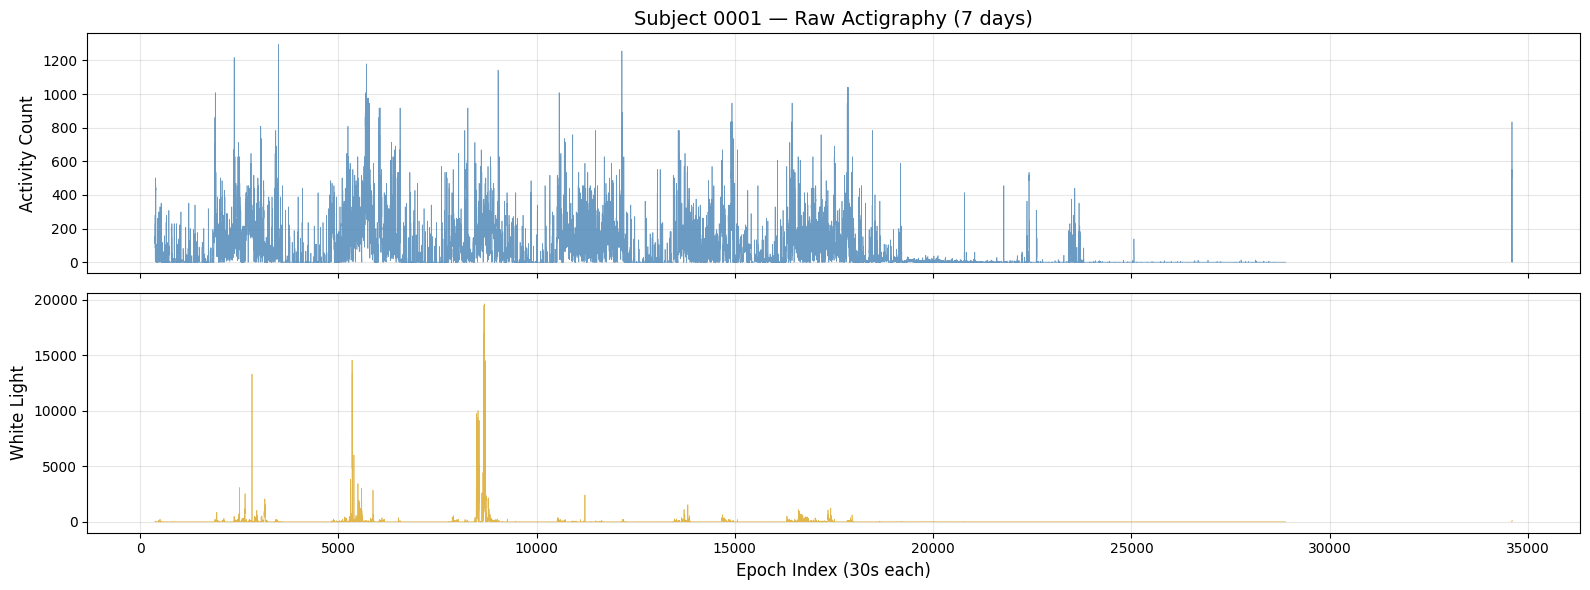

活动量统计: mean=66.63, median=1.00, max=1296


In [47]:
# 体动数据可视化 — 7天活动量
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# 上图: 活动量 (activity) — 反映了被试的运动强度
axes[0].plot(df_act_raw.index, df_act_raw['activity'], 
             color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_ylabel('Activity Count', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — Raw Actigraphy (7 days)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 下图: 光照数据 (whitelight) — 可用于推断就寝/起床时间
axes[1].plot(df_act_raw.index, df_act_raw['whitelight'], 
             color='goldenrod', linewidth=0.5, alpha=0.8)
axes[1].set_ylabel('White Light', fontsize=12)
axes[1].set_xlabel('Epoch Index (30s each)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'活动量统计: mean={df_act_raw["activity"].mean():.2f}, '
      f'median={df_act_raw["activity"].median():.2f}, '
      f'max={df_act_raw["activity"].max():.0f}')

In [48]:
# ===================================================================
# 1.2 ECG R点数据
# ===================================================================
# 来源: PSG 心电通道，自动检测 R 波峰值
# R点: 心电图上每次心跳的 QRS 波群的峰值点
# 从 R-R 间期的时间差可以推算心率: HR = 60000 / (RR_interval_ms)
df_rpt_raw = importer.load_single_r_point(MESA_PATH, SUBJ_INT)
print(f'R点数据: {df_rpt_raw.shape}')
print(f'  列名: {list(df_rpt_raw.columns)}')

# 计算 R-R 间期 (相邻两个 R 波之间的时间差，单位毫秒)
rr_intervals_raw = df_rpt_raw['seconds'].diff() * 1000  # 秒 → 毫秒
print(f'\nR-R 间期 (毫秒): mean={rr_intervals_raw.mean():.1f}, '
      f'std={rr_intervals_raw.std():.1f}, '
      f'min={rr_intervals_raw.min():.1f}, max={rr_intervals_raw.max():.1f}')
print(f'  对应心率 (bpm): mean={60000/rr_intervals_raw.mean():.1f}')

R点数据: (40471, 20)
  列名: ['epoch', 'RPoint', 'Start', 'End', 'STLevel1', 'STSlope1', 'STLevel2', 'STSlope2', 'Manual', 'Type', 'Class', 'PPoint', 'PStart', 'PEnd', 'TPoint', 'TStart', 'TEnd', 'TemplateID', 'seconds', 'stage']

R-R 间期 (毫秒): mean=972.7, std=2053.0, min=19.5, max=285781.2
  对应心率 (bpm): mean=61.7


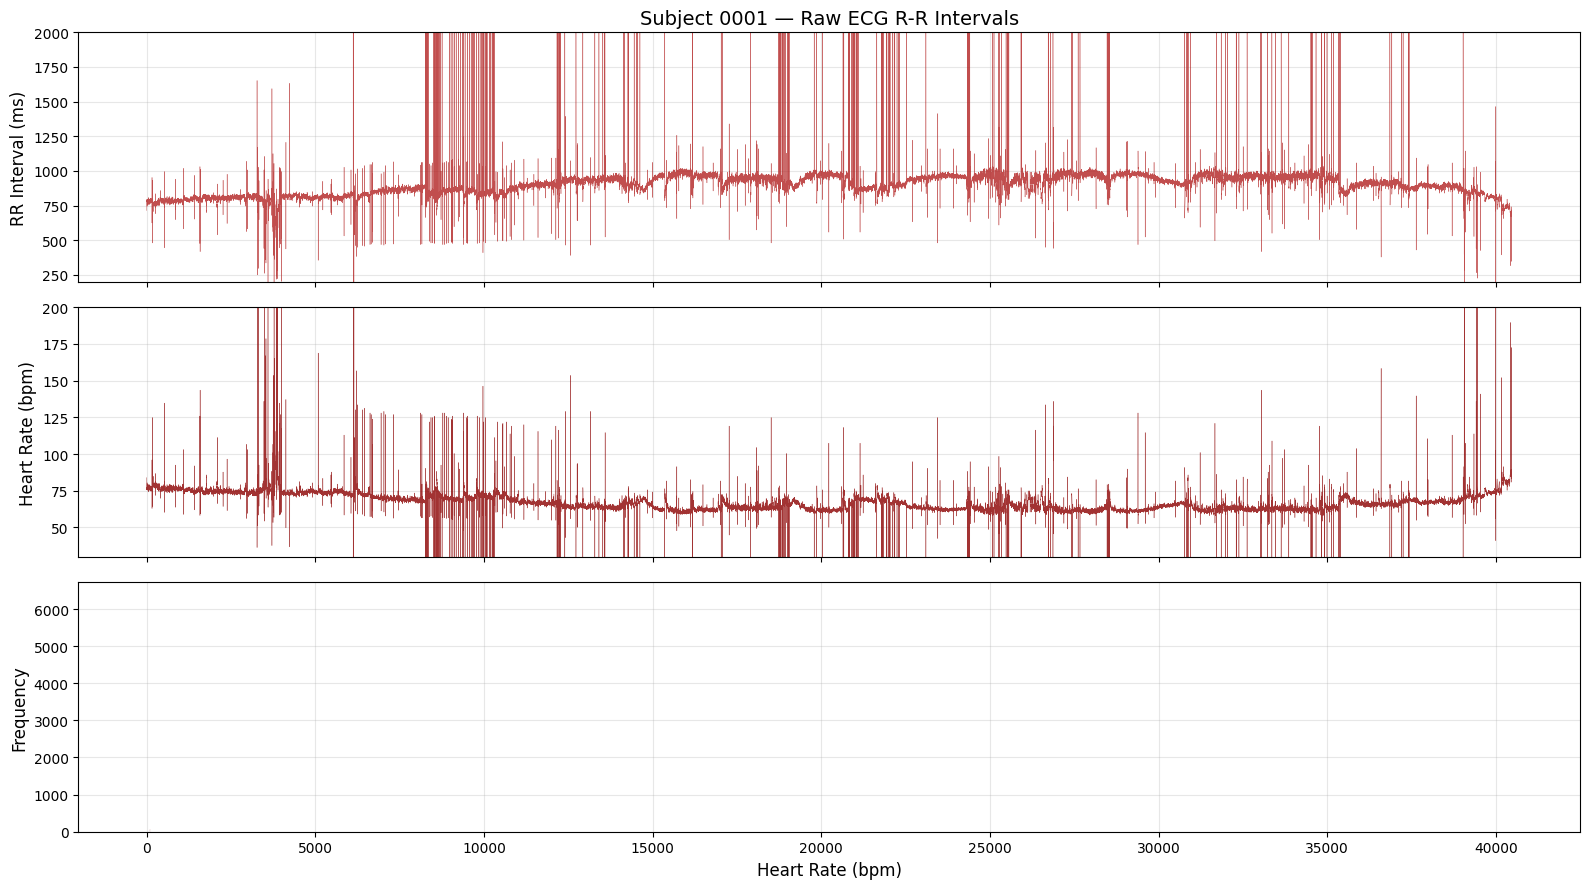

In [49]:
# ECG 数据可视化 — R-R 间期和心率
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# 上: R-R 间期 (每次心跳的时间间隔)
axes[0].plot(rr_intervals_raw.index, rr_intervals_raw.values, 
             color='firebrick', linewidth=0.3, alpha=0.8)
axes[0].set_ylabel('RR Interval (ms)', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — Raw ECG R-R Intervals', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(200, 2000)  # 过滤异常值, 正常RR在300-2000ms

# 中: 心率 (HR = 60000 / RR_interval)
hr_raw = 60000 / rr_intervals_raw.values
axes[1].plot(rr_intervals_raw.index, hr_raw, 
             color='darkred', linewidth=0.3, alpha=0.8)
axes[1].set_ylabel('Heart Rate (bpm)', fontsize=12)
axes[1].set_ylim(30, 200)
axes[1].grid(True, alpha=0.3)

# 下: 心率直方图
valid_hr = hr_raw[(hr_raw > 30) & (hr_raw < 200)]
axes[2].hist(valid_hr, bins=100, color='darkred', alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Heart Rate (bpm)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# ===================================================================
# 1.3 PSG 睡眠分期数据
# ===================================================================
# 来源: 临床多导睡眠图，由睡眠技师人工标注
# 标注标准: AASM (American Academy of Sleep Medicine)
# 原始标注 (每30秒一个epoch):
#   0=Wake, 1=N1, 2=N2, 3=N3, 4=N3, 5=REM, 6=未分类, 9=不在床
df_psg_raw = importer.load_single_psg(MESA_PATH, SUBJ_INT)
print(f'PSG 数据: {df_psg_raw.shape}')
print(f'  列名: {list(df_psg_raw.columns)}')

# 将原始 sleep 标注 (字符串格式 "sleep|W" 等) 转为数值
# 实际上 PSG 数据的 'sleep' 列包含 XML 中的事件标注
print(f'\nPSG time 列示例: {df_psg_raw["time"].iloc[:3].tolist()}')
print(f'PSG sleep 列示例: {df_psg_raw["sleep"].iloc[:3].tolist()}')

PSG 数据: (1439, 2)
  列名: ['time', 'sleep']

PSG time 列示例: [0, 30, 60]
PSG sleep 列示例: ['Wake|0', 'Wake|0', 'Wake|0']


转换后 PSG: (1439, 1)
  列名: ['sleep']
  sleep 列值分布 (0=Wake, 1=Sleep):
    0 (Wake): 752
    1 (Sleep): 687

注意: sleep_stage_convert_binary 只产生二分类，
      6-stage 分期 (Wake/N1/N2/N3/REM) 在 Step 3 的预处理中才会生成

原始 PSG 标注字符串种类:
  "Wake|0": 752
  "Stage 2 sleep|2": 455
  "Stage 1 sleep|1": 135
  "REM sleep|5": 78
  "Stage 3 sleep|3": 19


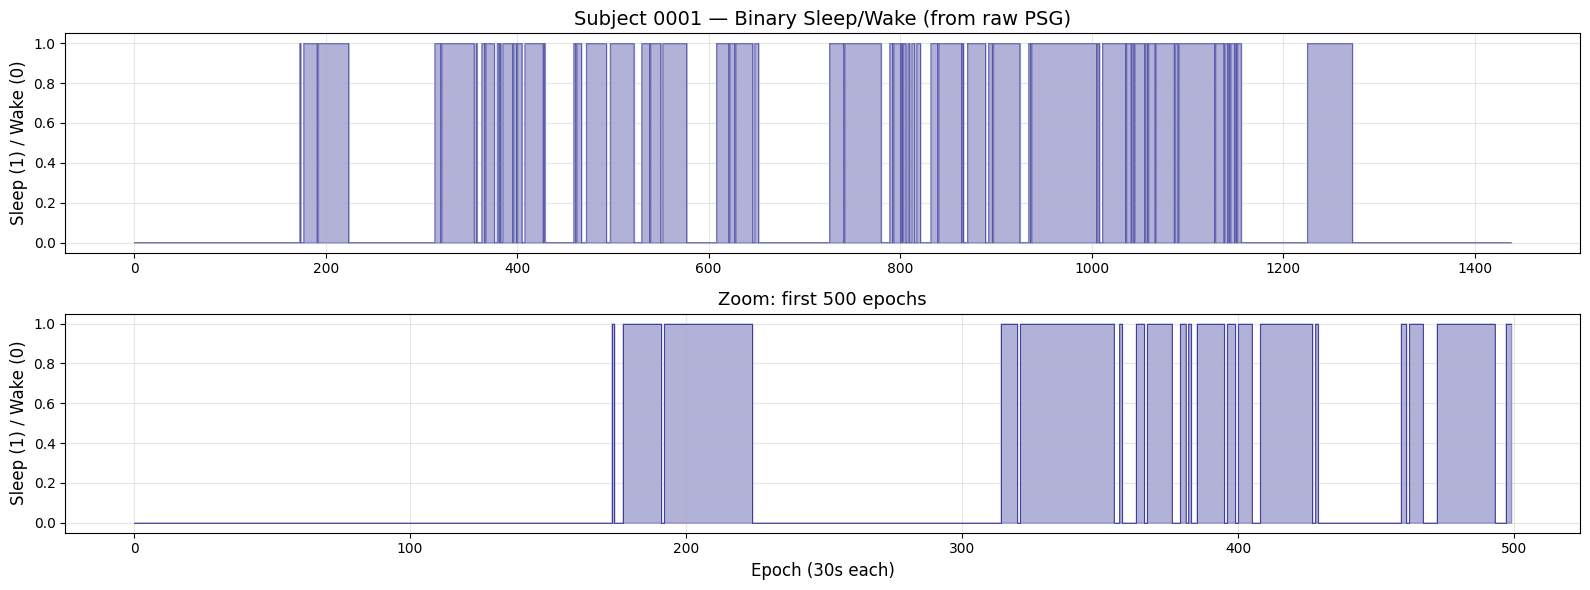

总睡眠时间: 5.7 小时 (687 epochs)
Sleep Efficiency: 47.7%


In [51]:
# PSG 睡眠分期标注 — 初步查看
# ===================================================================
# 此时的 PSG 原始数据只包含 sleep 列的字符串值 (如 "Wake|0", "N1|1"...)
# 在后面的 Step 3 预处理中才会进行:
#   - 二分类转换 (0=Wake, 1=Sleep) → sleep 列
#   - 多级分类 (5stage/4stage/3stage) → 从 AASM 6-stage 合并而来
# ===================================================================
from sleep_analysis.preprocessing.mesa_dataset.ground_truth import sleep_stage_convert_binary

# 将 PSG 原始标注转换为二分类 (此函数只做 Wake/Sleep 的二分类)
df_psg_binary = sleep_stage_convert_binary(df_psg_raw)
# 确保 sleep 列为数值类型 (sleep_stage_convert_binary 返回值可能是 object dtype)
sleep_values = df_psg_binary['sleep'].astype(float).values
n_epochs = len(sleep_values)

print(f'转换后 PSG: {df_psg_binary.shape}')
print(f'  列名: {list(df_psg_binary.columns)}')
print(f'  sleep 列值分布 (0=Wake, 1=Sleep):')
print(f'    0 (Wake): {(sleep_values==0).sum()}')
print(f'    1 (Sleep): {(sleep_values==1).sum()}')
print(f'\n注意: sleep_stage_convert_binary 只产生二分类，')
print(f'      6-stage 分期 (Wake/N1/N2/N3/REM) 在 Step 3 的预处理中才会生成')

# 查看原始 PSG 的标注字符串种类
raw_labels = df_psg_raw['sleep'].value_counts()
print(f'\n原始 PSG 标注字符串种类:')
for label, count in raw_labels.items():
    print(f'  "{label}": {count}')

# 绘制二分类睡眠图
fig, axes = plt.subplots(2, 1, figsize=(16, 6))
epoch_axis = np.arange(n_epochs)  # 用数值索引，避免 fill_between 类型问题

# 上图: 全夜的 Sleep/Wake 二分类
axes[0].plot(epoch_axis, sleep_values,
             color='navy', linewidth=0.3, drawstyle='steps-post', alpha=0.8)
axes[0].fill_between(epoch_axis, 0, sleep_values,
                     color='navy', step='post', alpha=0.3)
axes[0].set_ylabel('Sleep (1) / Wake (0)', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — Binary Sleep/Wake (from raw PSG)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 下图: 放大前500个epoch以看清细节
n_zoom = min(500, n_epochs)
axes[1].plot(range(n_zoom), sleep_values[:n_zoom],
             color='navy', linewidth=0.5, drawstyle='steps-post', alpha=0.8)
axes[1].fill_between(range(n_zoom), 0, sleep_values[:n_zoom],
                     color='navy', step='post', alpha=0.3)
axes[1].set_ylabel('Sleep (1) / Wake (0)', fontsize=12)
axes[1].set_xlabel('Epoch (30s each)', fontsize=12)
axes[1].set_title(f'Zoom: first {n_zoom} epochs', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 统计睡眠指标
total_sleep_epochs = (sleep_values == 1).sum()
total_sleep_hours = total_sleep_epochs / 120  # 30s per epoch → 120 epochs per hour
print(f'总睡眠时间: {total_sleep_hours:.1f} 小时 ({total_sleep_epochs} epochs)')
print(f'Sleep Efficiency: {total_sleep_epochs/n_epochs*100:.1f}%')

In [53]:
# ===================================================================
# 1.4 EDF 生理信号 (ECG 和呼吸)
# ===================================================================
# EDF (European Data Format): 生理信号的标准格式
# 每个被试的 EDF 包含一整晚的多通道数据
# 我们读取两个关键通道:
#   - EKG (ECG): 心电信号, 256Hz采样 → 一整晚约 1100万 个采样点
#   - Thor: 胸腔呼吸带, 256Hz采样 → 反映呼吸运动
from sleep_analysis.preprocessing.utils import extract_edf_channel

# 读取 ECG 通道
raw_ecg, epochs_ecg = extract_edf_channel(EDF_PATH, subj_id=SUBJ_INT, channel='EKG')
print(f'ECG 信号: {raw_ecg.shape}, 采样率 256Hz')
print(f'  时长: {len(raw_ecg) / 256 / 3600:.2f} 小时')
print(f'  范围: [{raw_ecg.min().item():.2f}, {raw_ecg.max().item():.2f}]')

# 读取呼吸通道
raw_resp, epochs_resp = extract_edf_channel(EDF_PATH, subj_id=SUBJ_INT, channel='Thor')
print(f'\n呼吸信号: {raw_resp.shape}, 采样率 256Hz')
print(f'  时长: {len(raw_resp) / 256 / 3600:.2f} 小时')
print(f'  范围: [{raw_resp.min().item():.2f}, {raw_resp.max().item():.2f}]')

Extracting EDF parameters from /srv/shared/psgdata/mesa/polysomnography/edfs/mesa-sleep-0001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECG 信号: (11058944, 1), 采样率 256Hz
  时长: 12.00 小时
  范围: [-0.01, 0.01]
Extracting EDF parameters from /srv/shared/psgdata/mesa/polysomnography/edfs/mesa-sleep-0001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

呼吸信号: (11058944, 1), 采样率 256Hz
  时长: 12.00 小时
  范围: [-0.00, 0.00]


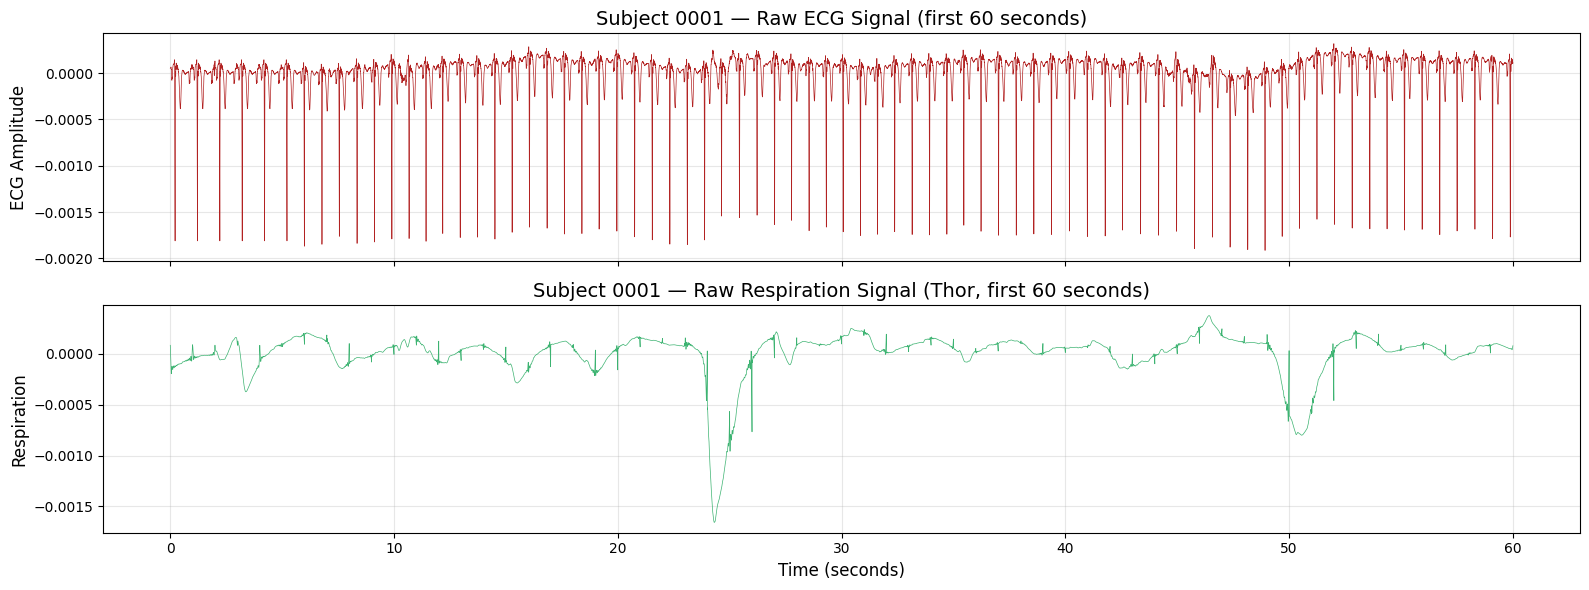

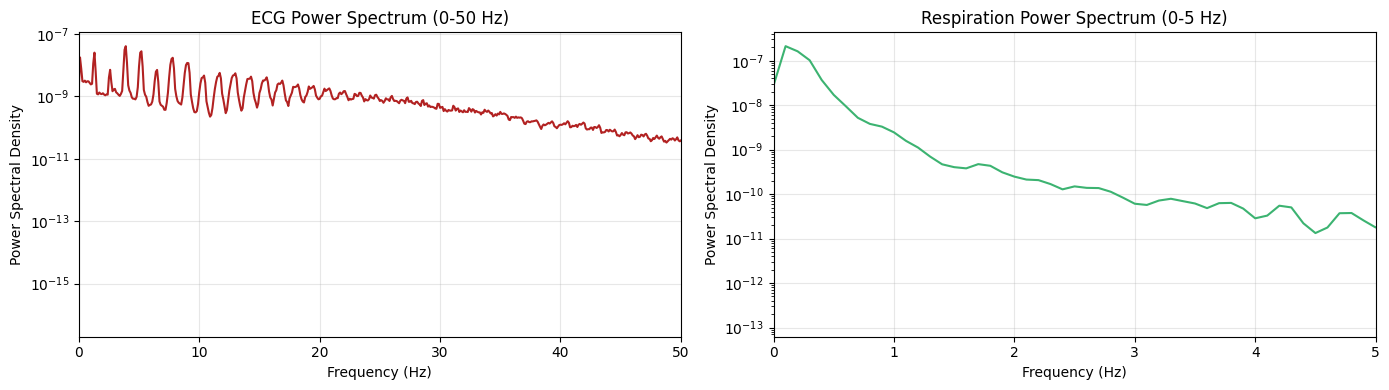

ECG 功率谱: QRS 复合波能量集中在 5-20 Hz
呼吸功率谱: 正常成人呼吸频率约 0.2 Hz (12次/分钟)


In [30]:
# EDF 原始信号可视化 (截取前60秒以看清细节)
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

sample_secs = 60  # 显示前60秒
sample_points = sample_secs * 256  # 256 samples/sec

# 上图: ECG (前60秒)
time_axis = np.arange(sample_points) / 256  # 秒
axes[0].plot(time_axis, raw_ecg.values[:sample_points, 0], 
             color='firebrick', linewidth=0.5)
axes[0].set_ylabel('ECG Amplitude', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — Raw ECG Signal (first 60 seconds)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 下图: 呼吸 (前60秒)
axes[1].plot(time_axis, raw_resp.values[:sample_points, 0],
             color='mediumseagreen', linewidth=0.5)
axes[1].set_ylabel('Respiration', fontsize=12)
axes[1].set_xlabel('Time (seconds)', fontsize=12)
axes[1].set_title(f'Subject {SUBJ_ID} — Raw Respiration Signal (Thor, first 60 seconds)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 频域分析: ECG 的功率谱
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ecg_signal = raw_ecg.values[:, 0]
from scipy import signal as scipy_signal
f, Pxx = scipy_signal.welch(ecg_signal[:256*300], fs=256, nperseg=256*10)  # 前5分钟
axes[0].semilogy(f, Pxx, color='firebrick')
axes[0].set_xlim(0, 50)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power Spectral Density')
axes[0].set_title('ECG Power Spectrum (0-50 Hz)')
axes[0].grid(True, alpha=0.3)

resp_signal = raw_resp.values[:, 0]
f, Pxx = scipy_signal.welch(resp_signal[:256*300], fs=256, nperseg=256*10)
axes[1].semilogy(f, Pxx, color='mediumseagreen')
axes[1].set_xlim(0, 5)  # 呼吸频率通常在 0.1-0.5 Hz
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power Spectral Density')
axes[1].set_title('Respiration Power Spectrum (0-5 Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('ECG 功率谱: QRS 复合波能量集中在 5-20 Hz')
print('呼吸功率谱: 正常成人呼吸频率约 0.2 Hz (12次/分钟)')

## Step 1: EDR 特征提取 (ECG-Derived Respiration)

**目标**: 从 ECG 心电信号中估算呼吸信号。

**原理**: 呼吸会引起胸腔容积变化, 进而影响心脏在胸腔中的位置和方向。
这会导致 ECG 波形的**振幅调制** (呼吸性窦性心律不齐) 和**基线漂移**。

**流程**: ECG原始信号 → EDR算法 → 呼吸波形 → 下采样32Hz → RRV特征

In [54]:
# ===================================================================
# Step 1: EDR 提取
# ===================================================================
from sleep_analysis.preprocessing.mesa_dataset.edr import _extract_edr, process_resp
from sleep_analysis.feature_extraction.mesa_datasst.rrv import extract_rrv_features_helper

# (1) 从 ECG 中提取呼吸信号 (EDR)
#     使用 Charlton 等人 2016 的方法:
#     检测 ECG 的 QRS 波群，提取 R 波振幅和 R-S 振幅
#     这些振幅的周期性变化反映了呼吸
edr_signal = _extract_edr(raw_ecg, sampling_rate=256)
print(f'EDR 呼吸信号: {edr_signal.respiratory_signal.shape}')

# (2) 下采样到 32Hz，并按 30秒 epoch 切分
resp_edr_df, epochs_edr = process_resp(edr_signal.respiratory_signal, epochs_ecg)
print(f'下采样后 EDR: {resp_edr_df.shape} (32Hz)')

# (3) 计算 RRV 特征 (滑动窗口法)
#     对 5分钟(150秒)、7分钟(210秒)、9分钟(270秒) 三种窗口
#     每种窗口计算一套 RRV 指标 (RMSSD, SDBB, CV等)
features_edr = extract_rrv_features_helper(resp_edr_df, nan_pad=0.0, sampling_rate=32)
print(f'EDR 特征: {features_edr.shape}')
print(f'  特征维度: {features_edr.shape[1]} 列')
print(f'  Epoch 数: {features_edr.shape[0]} (对应 {features_edr.shape[0]/2} 分钟)')

  0%|          | 0/1 [00:00<?, ?it/s]

EDR 呼吸信号: (11058944, 1)
下采样后 EDR: (1382368, 1) (32Hz)
handle Value-Error
handle Index-Error
handle Index-Error
handle Index-Error
handle Index-Error
handle Index-Error
handle Value-Error
handle Value-Error
handle Index-Error
handle Index-Error
handle Index-Error
handle Value-Error
handle Value-Error
handle Index-Error
handle Value-Error
length 70
EDR 特征: (1440, 70)
  特征维度: 70 列
  Epoch 数: 1440 (对应 720.0 分钟)


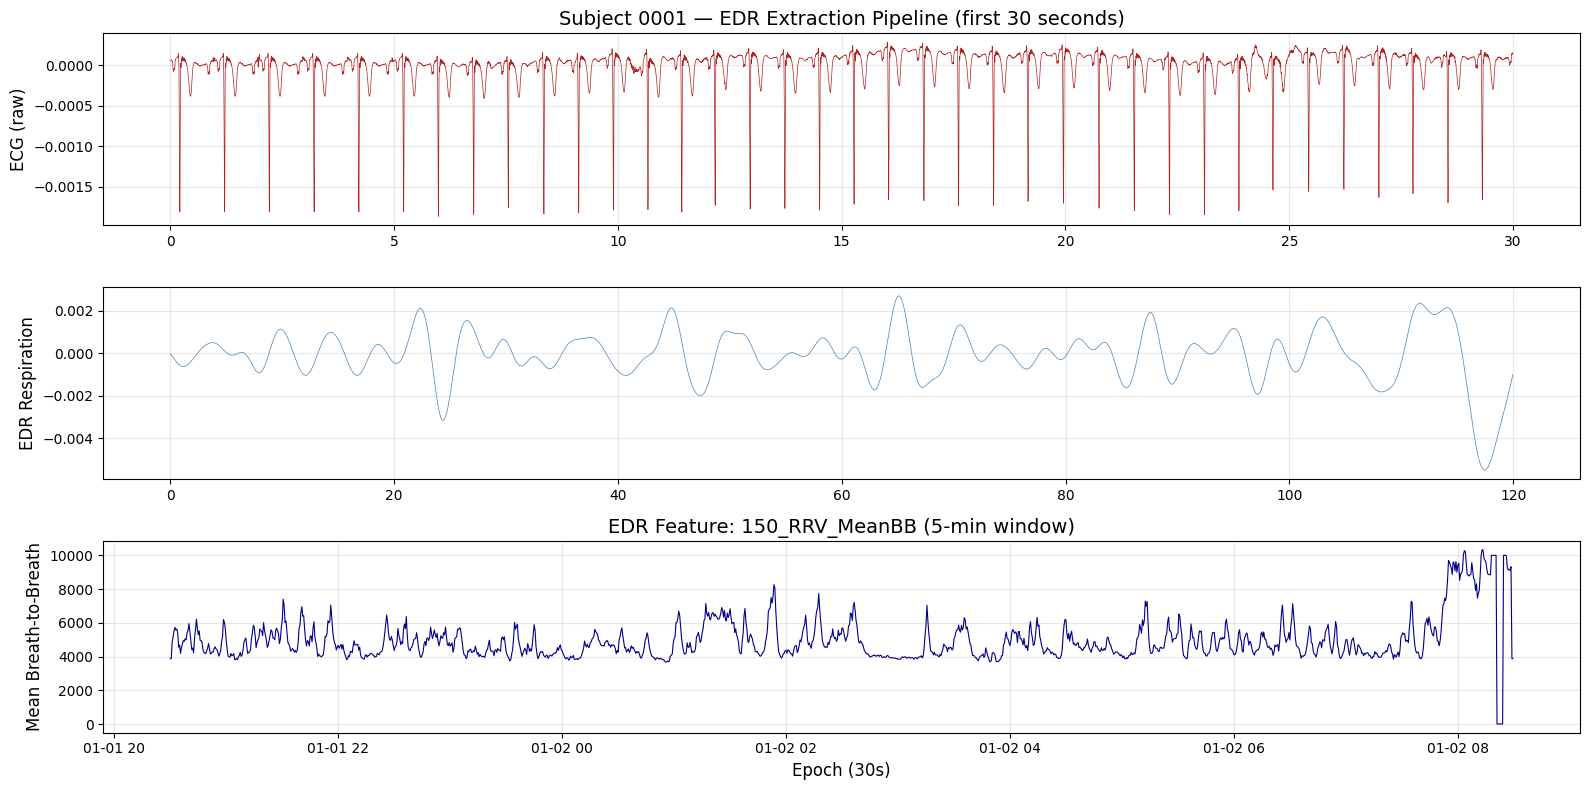

EDR 特征已保存到 /home/rdwang/repo/SleepStaging/temp/processed/edr_respiration_features_raw/


In [32]:
# EDR 提取结果可视化 — 对比原始 ECG 和提取的呼吸信号
fig, axes = plt.subplots(3, 1, figsize=(16, 8))

# 上图: 原始 ECG (前30秒)
n_secs = 30
n_points = n_secs * 256
t_sec = np.arange(n_points) / 256
axes[0].plot(t_sec, raw_ecg.values[:n_points, 0], color='firebrick', linewidth=0.5)
axes[0].set_ylabel('ECG (raw)', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — EDR Extraction Pipeline (first {n_secs} seconds)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 中图: EDR 提取的呼吸信号 (32Hz, 前2分钟)
n_resp = 2 * 60 * 32  # 2分钟 × 32Hz
t_resp = np.arange(min(n_resp, len(resp_edr_df))) / 32
axes[1].plot(t_resp, resp_edr_df.values[:len(t_resp), 0], 
             color='steelblue', linewidth=0.5)
axes[1].set_ylabel('EDR Respiration', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 下图: EDR 特征 — 呼吸率 (MeanBB = mean breath-to-breath interval)
# 选取 150_ (5分钟窗口) 的 MeanBB 特征
mean_bb_col = '150_RRV_MeanBB'
if mean_bb_col in features_edr.columns:
    axes[2].plot(features_edr.index, features_edr[mean_bb_col].values, 
                 color='darkblue', linewidth=0.8)
    axes[2].set_ylabel('Mean Breath-to-Breath', fontsize=12)
    axes[2].set_xlabel('Epoch (30s)', fontsize=12)
    axes[2].set_title(f'EDR Feature: {mean_bb_col} (5-min window)', fontsize=14)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 保存 EDR 特征
features_edr.to_csv(OUTPUT_DIR / f'edr_respiration_features_raw/edr_respiration{SUBJ_ID}.csv')
print(f'EDR 特征已保存到 {OUTPUT_DIR}/edr_respiration_features_raw/')

## Step 2: RRV 特征提取 (Respiratory Rate Variability)

**目标**: 从胸腔呼吸带信号中提取呼吸率变异性特征。

**与 EDR 的区别**: EDR 是从 ECG 间接估算呼吸，RRV 用的是真实的呼吸带测量。

**特征分类**:
- 时域: RMSSD, MeanBB, SDBB, CV 等 (呼吸周期的均值和变异)
- 频域: LF (0.04-0.15Hz), HF (0.15-0.4Hz) 功率
- 非线性: DFA (去趋势波动分析), 样本熵

In [33]:
# ===================================================================
# Step 2: RRV 提取
# ===================================================================

# (1) 下采样呼吸信号: 256Hz → 32Hz
resp_df, epochs_rrv = process_resp(raw_resp, epochs_resp)
print(f'下采样后呼吸信号: {resp_df.shape} (32Hz)')

# (2) 计算 RRV 特征
features_rrv = extract_rrv_features_helper(resp_df)
print(f'RRV 特征: {features_rrv.shape}')
print(f'  特征维度: {features_rrv.shape[1]} 列')
print(f'  列名前缀含义:')
print(f'    150_ = 5分钟滑动窗口 (150秒)')
print(f'    210_ = 7分钟滑动窗口 (210秒)')
print(f'    270_ = 9分钟滑动窗口 (270秒)')

下采样后呼吸信号: (1382368, 1) (32Hz)
length 70
RRV 特征: (1440, 70)
  特征维度: 70 列
  列名前缀含义:
    150_ = 5分钟滑动窗口 (150秒)
    210_ = 7分钟滑动窗口 (210秒)
    270_ = 9分钟滑动窗口 (270秒)


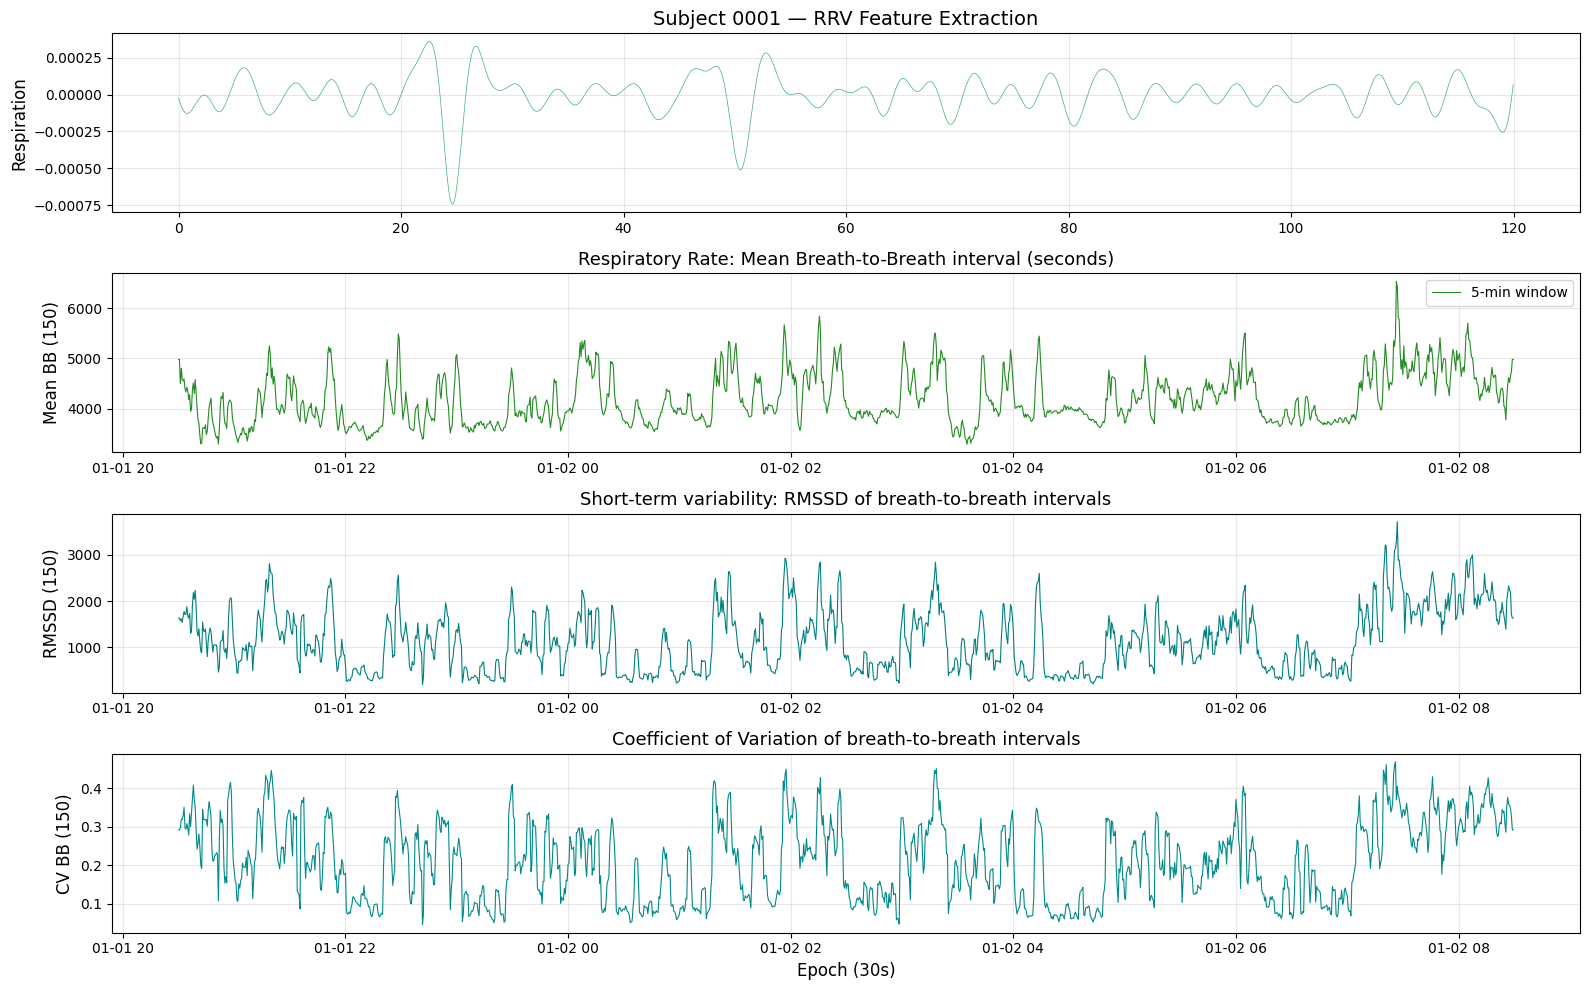

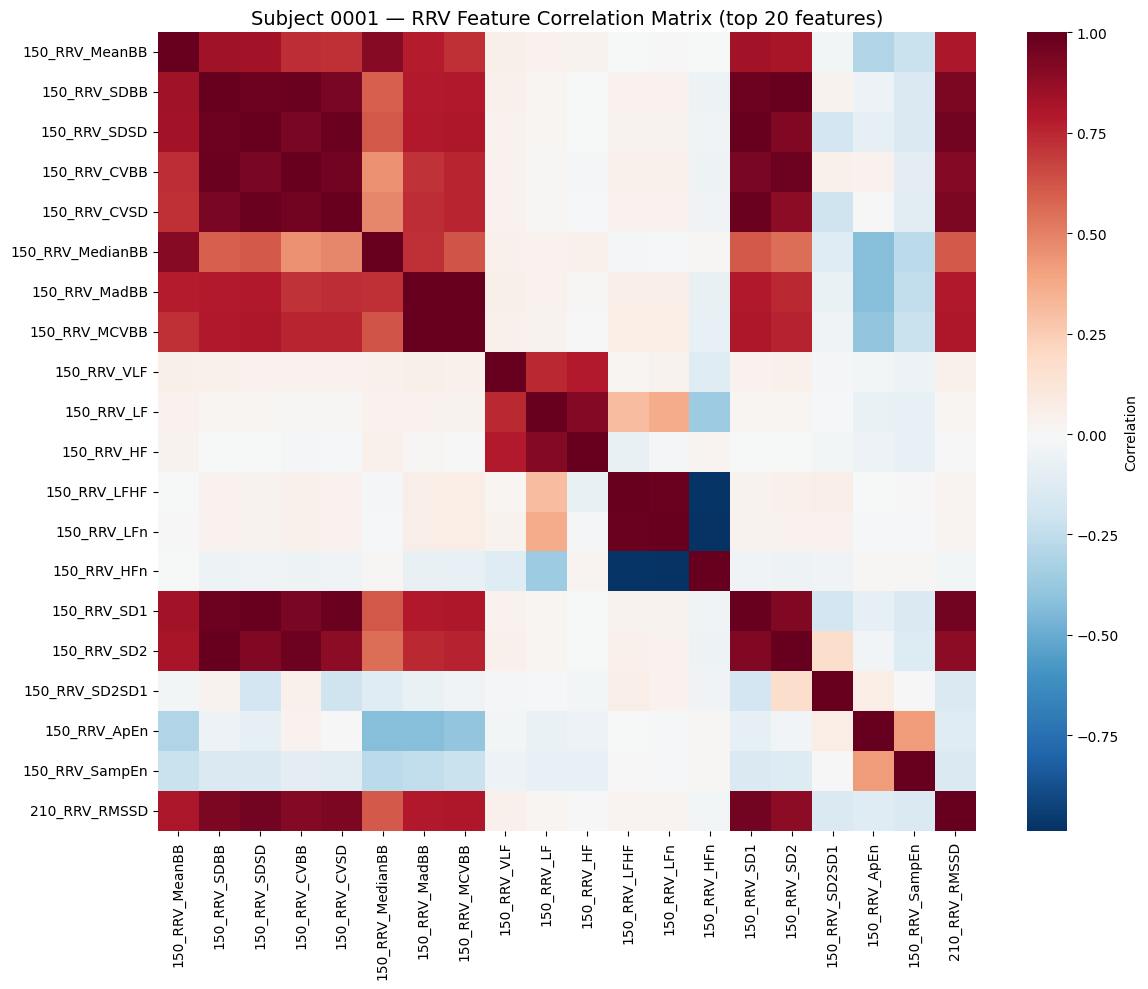

RRV 特征已保存到 /home/rdwang/repo/SleepStaging/temp/processed/respiration_features_raw/


In [34]:
# RRV 特征可视化 — 呼吸率和呼吸变异性
fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# 上图: 原始呼吸信号 (前2分钟, 32Hz)
n_show = min(2 * 60 * 32, len(resp_df))
t_show = np.arange(n_show) / 32
axes[0].plot(t_show, resp_df.values[:n_show, 0], color='mediumseagreen', linewidth=0.5)
axes[0].set_ylabel('Respiration', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — RRV Feature Extraction', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 呼吸率 (MeanBB = 平均呼吸间期)
axes[1].plot(features_rrv.index, features_rrv['150_RRV_MeanBB'].values, 
             color='forestgreen', linewidth=0.8, label='5-min window')
axes[1].set_ylabel('Mean BB (150)', fontsize=12)
axes[1].set_title('Respiratory Rate: Mean Breath-to-Breath interval (seconds)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# RMSSD (呼吸间期差值的均方根 = 短时变异)
axes[2].plot(features_rrv.index, features_rrv['150_RRV_RMSSD'].values, 
             color='teal', linewidth=0.8)
axes[2].set_ylabel('RMSSD (150)', fontsize=12)
axes[2].set_title('Short-term variability: RMSSD of breath-to-breath intervals', fontsize=13)
axes[2].grid(True, alpha=0.3)

# CV (变异系数 = std/mean, 反映总体变异性)
if '150_RRV_CVBB' in features_rrv.columns:
    axes[3].plot(features_rrv.index, features_rrv['150_RRV_CVBB'].values, 
                 color='darkcyan', linewidth=0.8)
    axes[3].set_ylabel('CV BB (150)', fontsize=12)
    axes[3].set_title('Coefficient of Variation of breath-to-breath intervals', fontsize=13)
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlabel('Epoch (30s)', fontsize=12)

plt.tight_layout()
plt.show()

# 特征相关性热图 (选取前20个特征)
fig, ax = plt.subplots(figsize=(12, 10))
top_features = features_rrv.iloc[:, 1:21]  # 跳过可能的索引列
corr = top_features.corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax, 
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Correlation'})
ax.set_title(f'Subject {SUBJ_ID} — RRV Feature Correlation Matrix (top 20 features)', fontsize=14)
plt.tight_layout()
plt.show()

# 保存 RRV 特征
features_rrv.to_csv(OUTPUT_DIR / f'respiration_features_raw/respiration{SUBJ_ID}.csv')
print(f'RRV 特征已保存到 {OUTPUT_DIR}/respiration_features_raw/')

## Step 3: MESA 数据预处理

**目标**: 将被试的全部数据流 (体动、ECG、PSG、呼吸、EDR) 进行:

1. **清洗**: 去除异常值、插值缺失值、剔除质量差的 epoch
2. **对齐**: 所有信号统一到相同的 30秒 epoch 时间轴
3. **标注**: PSG 睡眠分期转换为多级分类 (binary / 3-stage / 4-stage / 5-stage)
4. **筛选**: 排除睡眠时间不足 2 小时的被试

这是整个管线中**最关键也最复杂**的一步。

In [35]:
# ===================================================================
# Step 3: 数据预处理
# ===================================================================
from sleep_analysis.preprocessing.mesa_dataset.preprocess_mesa import _clean_data_helper
from sleep_analysis.preprocessing.mesa_dataset.utils import match_exclusion_criteria

# 加载重叠表 (记录体动和PSG同时可用的时间段)
overlap = pd.read_csv(MESA_PATH / 'overlap/mesa-actigraphy-psg-overlap.csv')

# 加载数据集信息表 (用于质量筛选)
dataset_info = pd.read_csv(MESA_PATH / 'datasets/mesa-sleep-dataset-0.5.0.csv').set_index('mesaid')

# 检查是否被排除
if match_exclusion_criteria(dataset_info, SUBJ_ID):
    print(f'被试 {SUBJ_ID} 被质量筛选排除!')
else:
    print(f'被试 {SUBJ_ID} 通过质量筛选')
    
    # ★ 核心步骤: 清洗+对齐+标注 ★
    # 这会调用 _clean_data_helper, 内部执行:
    #   1. 呼吸特征校验 (check_resp_features)
    #   2. R点 → HR 处理 (process_rpoint)
    #   3. PSG → 睡眠分期转换 (sleep_stage_convert_binary)
    #   4. 体动数据清洗和裁剪 (process_actigraphy)
    #   5. 所有数据流对齐到统一 epoch 时间轴 (align_datastreams)
    #   6. 写入清洗后的数据
    try:
        _clean_data_helper(
            df_act_raw, df_rpt_raw, df_psg_raw,
            importer.load_single_resp_features(OUTPUT_DIR, SUBJ_INT),  # 用刚才保存的
            importer.load_single_edr_feature(OUTPUT_DIR, SUBJ_INT),    # 用刚才保存的
            overlap, SUBJ_INT
        )
        print(f'Subject {SUBJ_ID}: 预处理完成!')
    except Exception as e:
        print(f'Subject {SUBJ_ID}: 失败 — {e}')
        # 如果 OUTPUT_DIR 中没有, 尝试从全局 PROCESSED_PATH 加载
        print('尝试从全局处理目录加载...')
        _clean_data_helper(
            df_act_raw, df_rpt_raw, df_psg_raw,
            importer.load_single_resp_features(PROCESSED_PATH, SUBJ_INT),
            importer.load_single_edr_feature(PROCESSED_PATH, SUBJ_INT),
            overlap, SUBJ_INT
        )
        print(f'Subject {SUBJ_ID}: 从全局目录预处理完成!')

Subj - 0001 - Actigraphy quality insufficient
被试 0001 被质量筛选排除!


In [36]:
# 预处理结果可视化 — 清洗后的对齐数据
import mesa_data_importer as importer_mod

# 读取预处理产生的清洗后数据
# _clean_data_helper 写入 PROCESSED_PATH (全局), 我们从中读取
df_clean = pd.read_csv(PROCESSED_PATH / f'actigraph_data_clean/actigraph_data_clean{SUBJ_ID}.csv')
print(f'清洗后数据: {df_clean.shape}')
print(f'列名: {list(df_clean.columns)}')
print(f'\n各列含义:')
print(f'  line       — epoch 编号 (与原始体动数据对齐)')
print(f'  activity   — 活动量 (清洗后)')
print(f'  linetime   — 时间戳')
print(f'  sleep      — 二分类: 0=Wake, 1=Sleep')
print(f'  HR         — 心率 (bpm)')
print(f'  stage      — AASM 原始分期 (0-5, 6, 9)')
print(f'  5stage     — 5阶段 (Wake/N1/N2/N3/REM)')
print(f'  4stage     — 4阶段 (Wake/Light/Deep/REM)')
print(f'  3stage     — 3阶段 (Wake/NREM/REM)')
print(f'  epoch      — epoch 序号')

清洗后数据: (1262, 11)
列名: ['line', 'activity', 'linetime', 'sleep', 'HR', 'stage', '5stage', '4stage', '3stage', 'epoch', 'epoch.1']

各列含义:
  line       — epoch 编号 (与原始体动数据对齐)
  activity   — 活动量 (清洗后)
  linetime   — 时间戳
  sleep      — 二分类: 0=Wake, 1=Sleep
  HR         — 心率 (bpm)
  stage      — AASM 原始分期 (0-5, 6, 9)
  5stage     — 5阶段 (Wake/N1/N2/N3/REM)
  4stage     — 4阶段 (Wake/Light/Deep/REM)
  3stage     — 3阶段 (Wake/NREM/REM)
  epoch      — epoch 序号


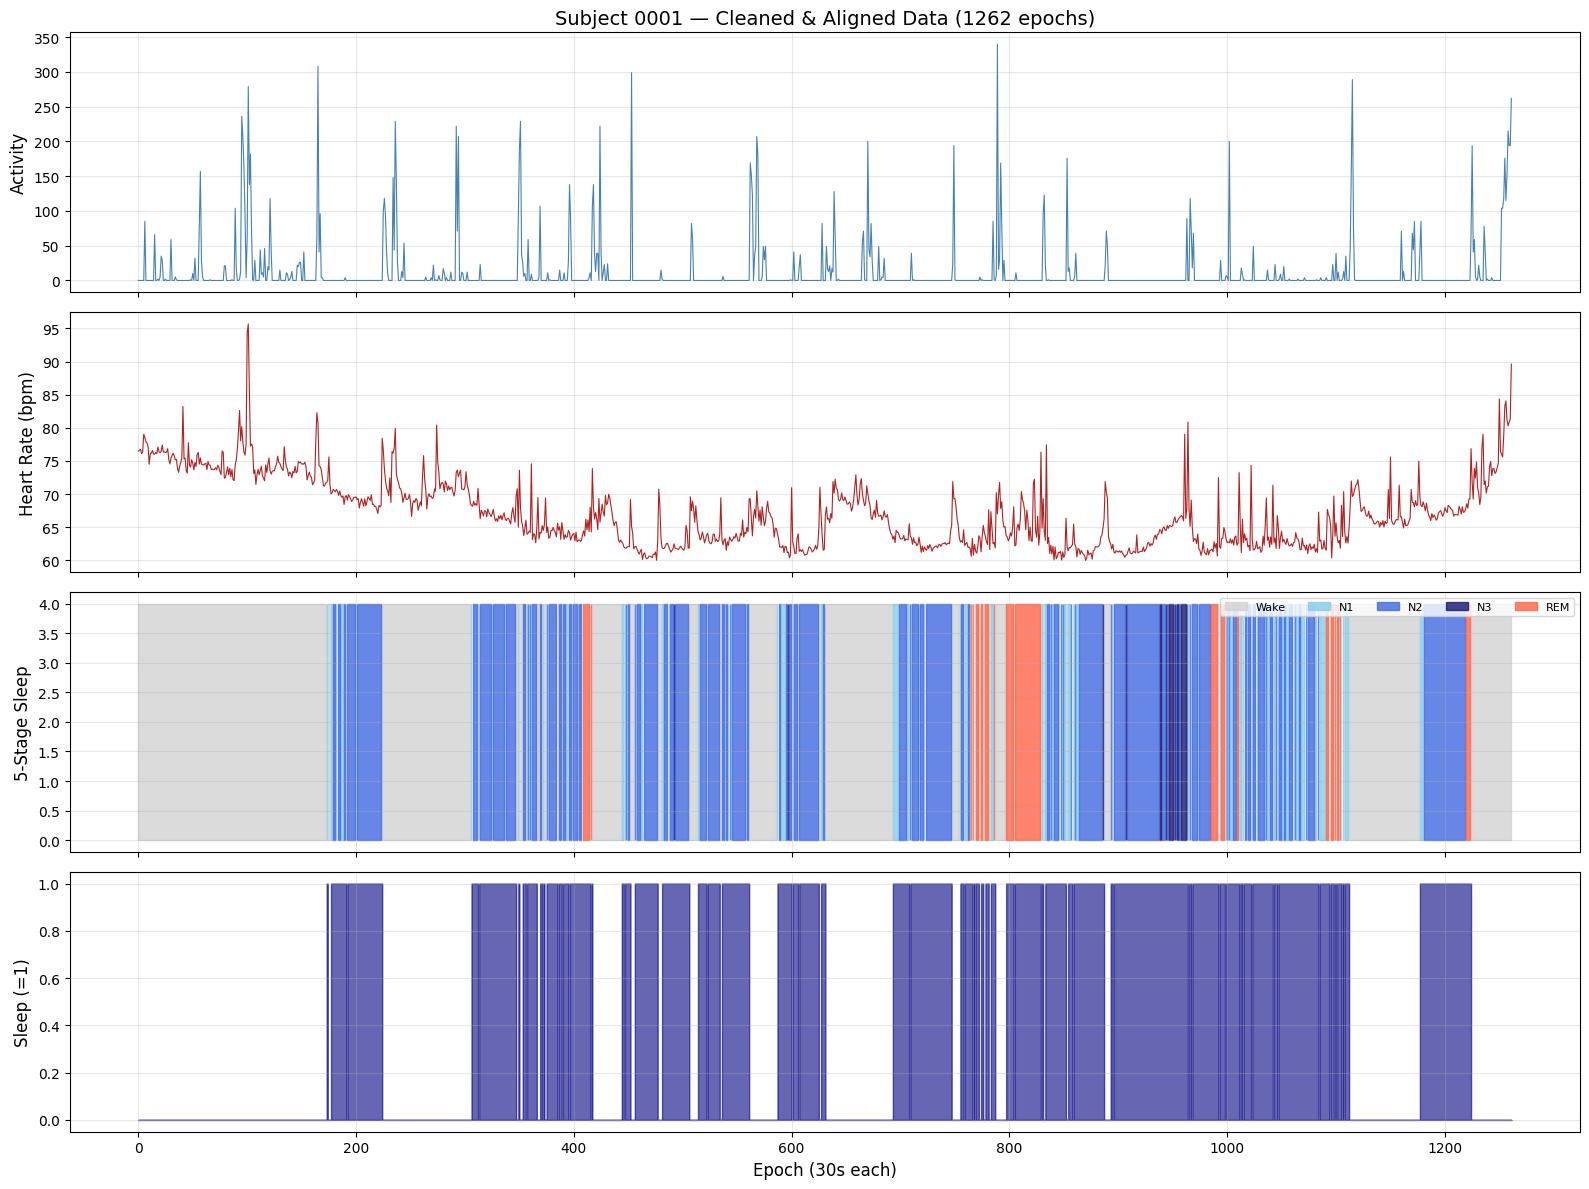

=== 清洗后数据统计 ===
总 epochs: 1262
Sleep epochs: 687 (54.4%)
总睡眠时间: 5.7 小时
平均心率: 67.1 bpm (sleep: 63.9, wake: 70.9)
平均活动量: 11.909 (sleep: 2.787, wake: 22.807)
  Stage 0 (Wake): 575 epochs (45.6%)
  Stage 1 (N1): 135 epochs (10.7%)
  Stage 2 (N2): 455 epochs (36.1%)
  Stage 3 (N3): 19 epochs (1.5%)
  Stage 4 (REM): 78 epochs (6.2%)


In [37]:
# 清洗后数据的全景可视化
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# 图1: 活动量
axes[0].plot(df_clean.index, df_clean['activity'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Activity', fontsize=12)
axes[0].set_title(f'Subject {SUBJ_ID} — Cleaned & Aligned Data ({df_clean.shape[0]} epochs)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 图2: 心率
axes[1].plot(df_clean.index, df_clean['HR'], color='firebrick', linewidth=0.8)
axes[1].set_ylabel('Heart Rate (bpm)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 图3: 5阶段睡眠图
stages_5 = df_clean['5stage'].values
stage_colors = {0: '#d3d3d3', 1: '#87CEEB', 2: '#4169E1', 3: '#191970', 4: '#FF6347'}
stage_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
for s_val in sorted(set(stages_5)):
    mask = stages_5 == s_val
    axes[2].fill_between(range(len(stages_5)), 4, where=mask,
                         color=stage_colors.get(s_val, 'gray'),
                         label=stage_names.get(s_val, str(s_val)),
                         step='post', alpha=0.8)
axes[2].set_ylabel('5-Stage Sleep', fontsize=12)
axes[2].legend(loc='upper right', ncol=5, fontsize=8)
axes[2].grid(True, alpha=0.3)

# 图4: 二分类 Sleep/Wake
axes[3].fill_between(range(len(df_clean)), 0, df_clean['sleep'].values,
                     color='navy', step='post', alpha=0.6)
axes[3].set_ylabel('Sleep (=1)', fontsize=12)
axes[3].set_xlabel('Epoch (30s each)', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 统计摘要
print('=== 清洗后数据统计 ===')
print(f'总 epochs: {len(df_clean)}')
print(f'Sleep epochs: {(df_clean["sleep"]==1).sum()} ({(df_clean["sleep"]==1).sum()/len(df_clean)*100:.1f}%)')
print(f'总睡眠时间: {(df_clean["sleep"]==1).sum()/120:.1f} 小时')
print(f'平均心率: {df_clean["HR"].mean():.1f} bpm (sleep: {df_clean[df_clean["sleep"]==1]["HR"].mean():.1f}, wake: {df_clean[df_clean["sleep"]==0]["HR"].mean():.1f})')
print(f'平均活动量: {df_clean["activity"].mean():.3f} (sleep: {df_clean[df_clean["sleep"]==1]["activity"].mean():.3f}, wake: {df_clean[df_clean["sleep"]==0]["activity"].mean():.3f})')
for k, v in df_clean['5stage'].value_counts().sort_index().items():
    print(f'  Stage {int(k)} ({stage_names.get(k, "?")}): {v} epochs ({v/len(df_clean)*100:.1f}%)')

## Step 4: 体动特征提取 (Actigraphy Features)

**目标**: 从清洗后的活动量时间序列中提取丰富的时序特征。

**方法**: 对 1~20 个 epoch 的滑动窗口，计算多种统计量:

| 统计量 | 说明 |
|---|---|
| mean, median | 窗口内的平均/中位活动水平 |
| std, var | 活动量的波动程度 |
| max, min | 窗口内的极值 |
| skew, kurt | 偏度和峰度 (分布形状) |
| nat | 非零活动的时间比例 |
| anyact | 是否有任何活动 (binary) |

每种统计量有 **centered** (窗口居中) 和 **non-centered** (窗口靠前) 两种模式。

**维度**: 20 窗口 × 18 统计量/变换 = 370 维

In [38]:
# ===================================================================
# Step 4: 体动特征提取
# ===================================================================
from sleep_analysis.feature_extraction.mesa_datasst.actigraphy import calc_actigraph_features

act_features = calc_actigraph_features(df_clean['activity'])
print(f'体动特征: {act_features.shape}')
print(f'  370 维 = (18种统计量/变换) × (20个窗口大小) + 2个额外列 (Act, LocAct)')
print(f'\n列名示例 (前20列):')
for col in act_features.columns[:20]:
    print(f'  {col}')
print(f'  ... (共 {len(act_features.columns)} 列)')

体动特征: (1262, 370)
  370 维 = (18种统计量/变换) × (20个窗口大小) + 2个额外列 (Act, LocAct)

列名示例 (前20列):
  _acc_mean_1
  _acc_mean_centered_1
  _acc_median_1
  _acc_median_centered_1
  _acc_std_1
  _acc_std_centered_1
  _acc_max_1
  _acc_max_centered_1
  _acc_min_1
  _acc_min_centered_1
  _acc_var_1
  _acc_var_centered_1
  _acc_nat_1
  _acc_nat_centered_1
  _acc_anyact_1
  _acc_anyact_centered_1
  _acc_mean_2
  _acc_mean_centered_2
  _acc_median_2
  _acc_median_centered_2
  ... (共 370 列)


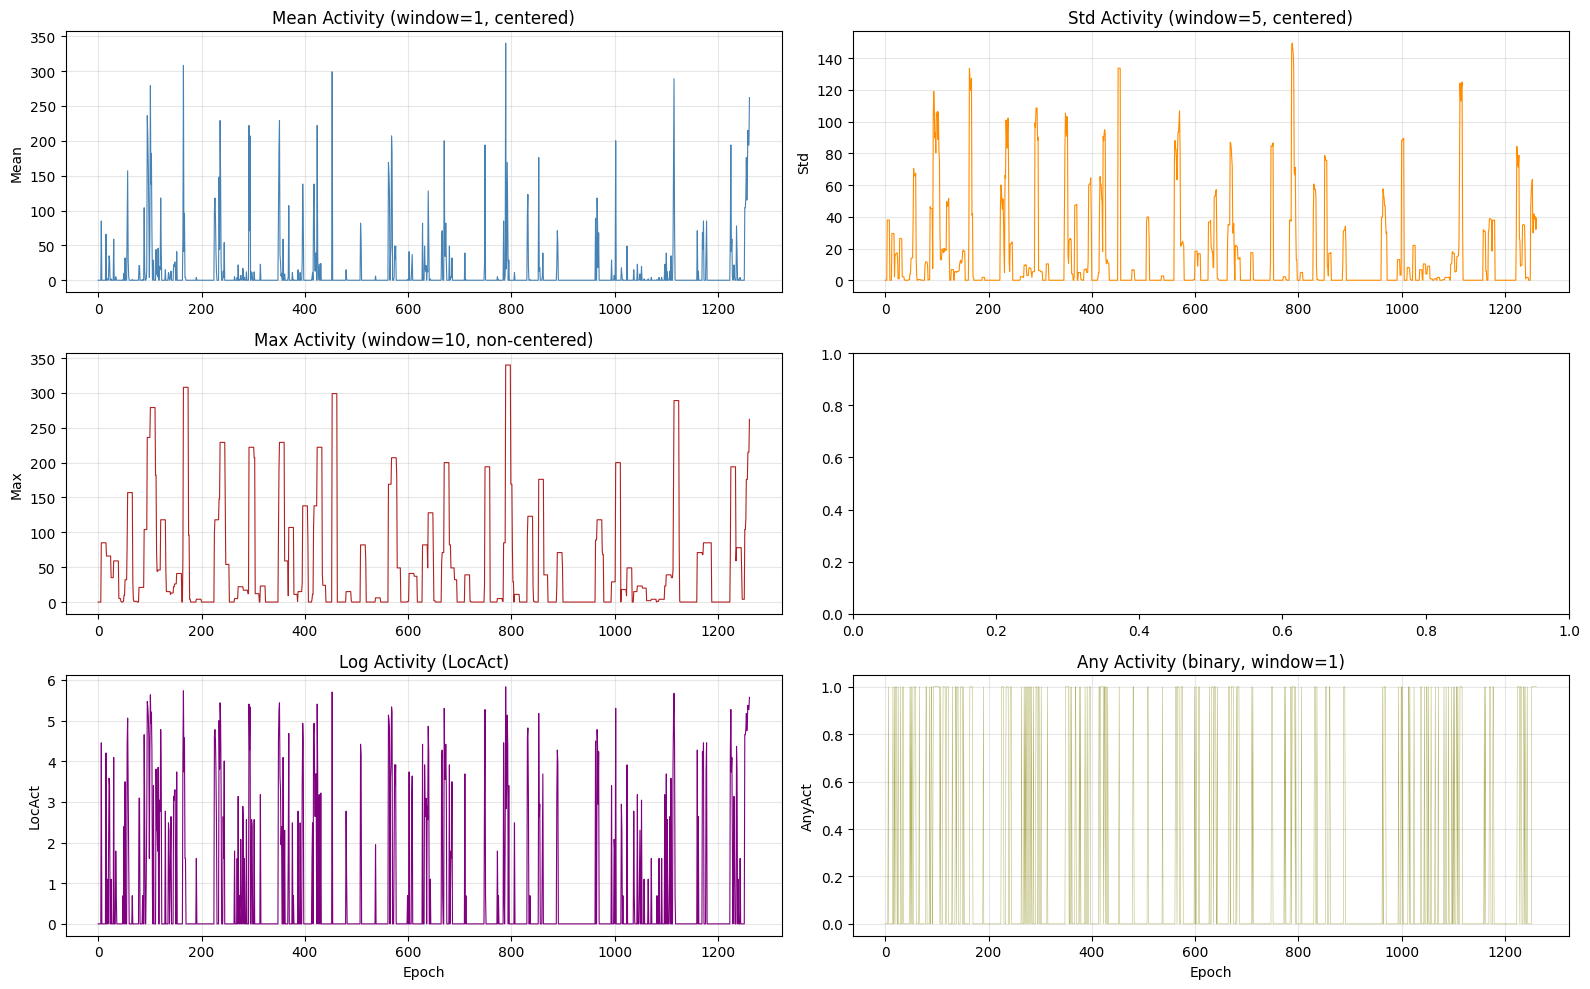

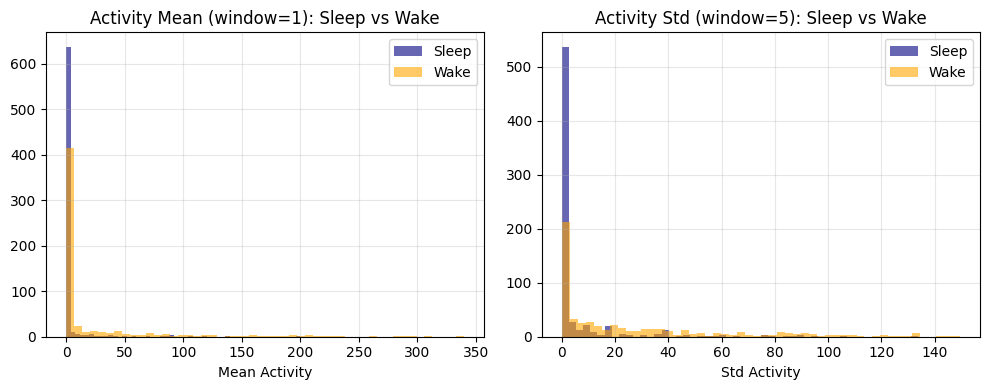

体动特征已保存到 /home/rdwang/repo/SleepStaging/temp/processed/actigraph_features/


In [39]:
# 体动特征可视化
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# 选取代表性的特征列进行展示
# (1) 活动均值 (窗口=1 epoch, centered)
axes[0, 0].plot(act_features['_acc_mean_1'], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Mean Activity (window=1, centered)', fontsize=12)
axes[0, 0].set_ylabel('Mean')
axes[0, 0].grid(True, alpha=0.3)

# (2) 活动标准差 (窗口=5 epoch, centered)
axes[0, 1].plot(act_features['_acc_std_centered_5'], color='darkorange', linewidth=0.8)
axes[0, 1].set_title('Std Activity (window=5, centered)', fontsize=12)
axes[0, 1].set_ylabel('Std')
axes[0, 1].grid(True, alpha=0.3)

# (3) 活动最大值 (窗口=10 epoch)
axes[1, 0].plot(act_features['_acc_max_10'], color='firebrick', linewidth=0.8)
axes[1, 0].set_title('Max Activity (window=10, non-centered)', fontsize=12)
axes[1, 0].set_ylabel('Max')
axes[1, 0].grid(True, alpha=0.3)

# (4) 非零活动比例 (窗口=20 epoch)
if '_acc_nat_centered_20' in act_features.columns:
    axes[1, 1].plot(act_features['_acc_nat_centered_20'], color='teal', linewidth=0.8)
    axes[1, 1].set_title('Non-zero Activity Time Ratio (window=20, centered)', fontsize=12)
    axes[1, 1].set_ylabel('NAT ratio')
    axes[1, 1].grid(True, alpha=0.3)

# (5) 对数活动量 (LocAct = log(activity+1))
axes[2, 0].plot(act_features['_acc_LocAct'], color='purple', linewidth=0.8)
axes[2, 0].set_title('Log Activity (LocAct)', fontsize=12)
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('LocAct')
axes[2, 0].grid(True, alpha=0.3)

# (6) 任意活动标记
axes[2, 1].plot(act_features['_acc_anyact_1'], color='olive', linewidth=0.3, alpha=0.7)
axes[2, 1].set_title('Any Activity (binary, window=1)', fontsize=12)
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('AnyAct')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 特征分布对比: sleep vs wake 的 activity mean
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sleep_mask = df_clean['sleep'] == 1
axes[0].hist(act_features.loc[sleep_mask, '_acc_mean_1'], bins=50, 
             alpha=0.6, label='Sleep', color='navy')
axes[0].hist(act_features.loc[~sleep_mask, '_acc_mean_1'], bins=50, 
             alpha=0.6, label='Wake', color='orange')
axes[0].set_title('Activity Mean (window=1): Sleep vs Wake')
axes[0].set_xlabel('Mean Activity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(act_features.loc[sleep_mask, '_acc_std_centered_5'], bins=50, 
             alpha=0.6, label='Sleep', color='navy')
axes[1].hist(act_features.loc[~sleep_mask, '_acc_std_centered_5'], bins=50, 
             alpha=0.6, label='Wake', color='orange')
axes[1].set_title('Activity Std (window=5): Sleep vs Wake')
axes[1].set_xlabel('Std Activity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 保存
act_features.to_csv(OUTPUT_DIR / f'actigraph_features/actigraph_features{SUBJ_ID}.csv', index=False)
print(f'体动特征已保存到 {OUTPUT_DIR}/actigraph_features/')

## Step 5: HRV 特征提取 (Heart Rate Variability)

**目标**: 从清洗后的 RR 间期数据中提取心率变异性特征。

**HRV 是睡眠分期的重要指标**: 自主神经系统在 Wake/NREM/REM 中有不同的活动模式。

**特征类别**:

| 类别 | 指标 | 生理含义 |
|---|---|---|
| 时域 | SDNN, RMSSD, pNN50 | 总体和短时心率变异性, RMSSD反映副交感活动 |
| 频域 | LF (0.04-0.15Hz), HF (0.15-0.4Hz) | LF反映交感+副交感, HF反映副交感 |
| 非线性 | SD1, SD2 (Poincare) | SD1=短时变异, SD2=长时变异 |
| 非线性 | CSI, CVI | 心脏交感指数和迷走指数 |
| 几何 | triangular_index | RR间期直方图的几何形态 |

**维度**: 31 维 (去掉 tinn 和 epoch 后 29 维)

In [40]:
# ===================================================================
# Step 5: HRV 特征提取
# ===================================================================
from sleep_analysis.feature_extraction.mesa_datasst.hrv import calc_hrv_features

# 读取清洗后的 ECG 数据
df_ecg_clean = pd.read_csv(PROCESSED_PATH / f'ecg_data_clean/ecg_data_clean{SUBJ_ID}.csv')
print(f'清洗后 ECG: {df_ecg_clean.shape}')
print(f'列名: {list(df_ecg_clean.columns[:10])}...')

# 计算 HRV 特征
hrv_features = calc_hrv_features(df_ecg_clean)
print(f'\nHRV 特征: {hrv_features.shape}')
print(f'\n特征列名 (前20):')
for col in hrv_features.columns[:20]:
    print(f'  {col}')

清洗后 ECG: (40269, 22)
列名: ['epoch', 'RPoint', 'Start', 'End', 'STLevel1', 'STSlope1', 'STLevel2', 'STSlope2', 'Manual', 'Type']...

HRV 特征: (1262, 31)

特征列名 (前20):
  _hrv_mean_nni
  _hrv_sdnn
  _hrv_sdsd
  _hrv_nni_50
  _hrv_pnni_50
  _hrv_nni_20
  _hrv_pnni_20
  _hrv_rmssd
  _hrv_median_nni
  _hrv_range_nni
  _hrv_cvsd
  _hrv_cvnni
  _hrv_mean_hr
  _hrv_max_hr
  _hrv_min_hr
  _hrv_std_hr
  _hrv_lf
  _hrv_hf
  _hrv_lf_hf_ratio
  _hrv_lfnu


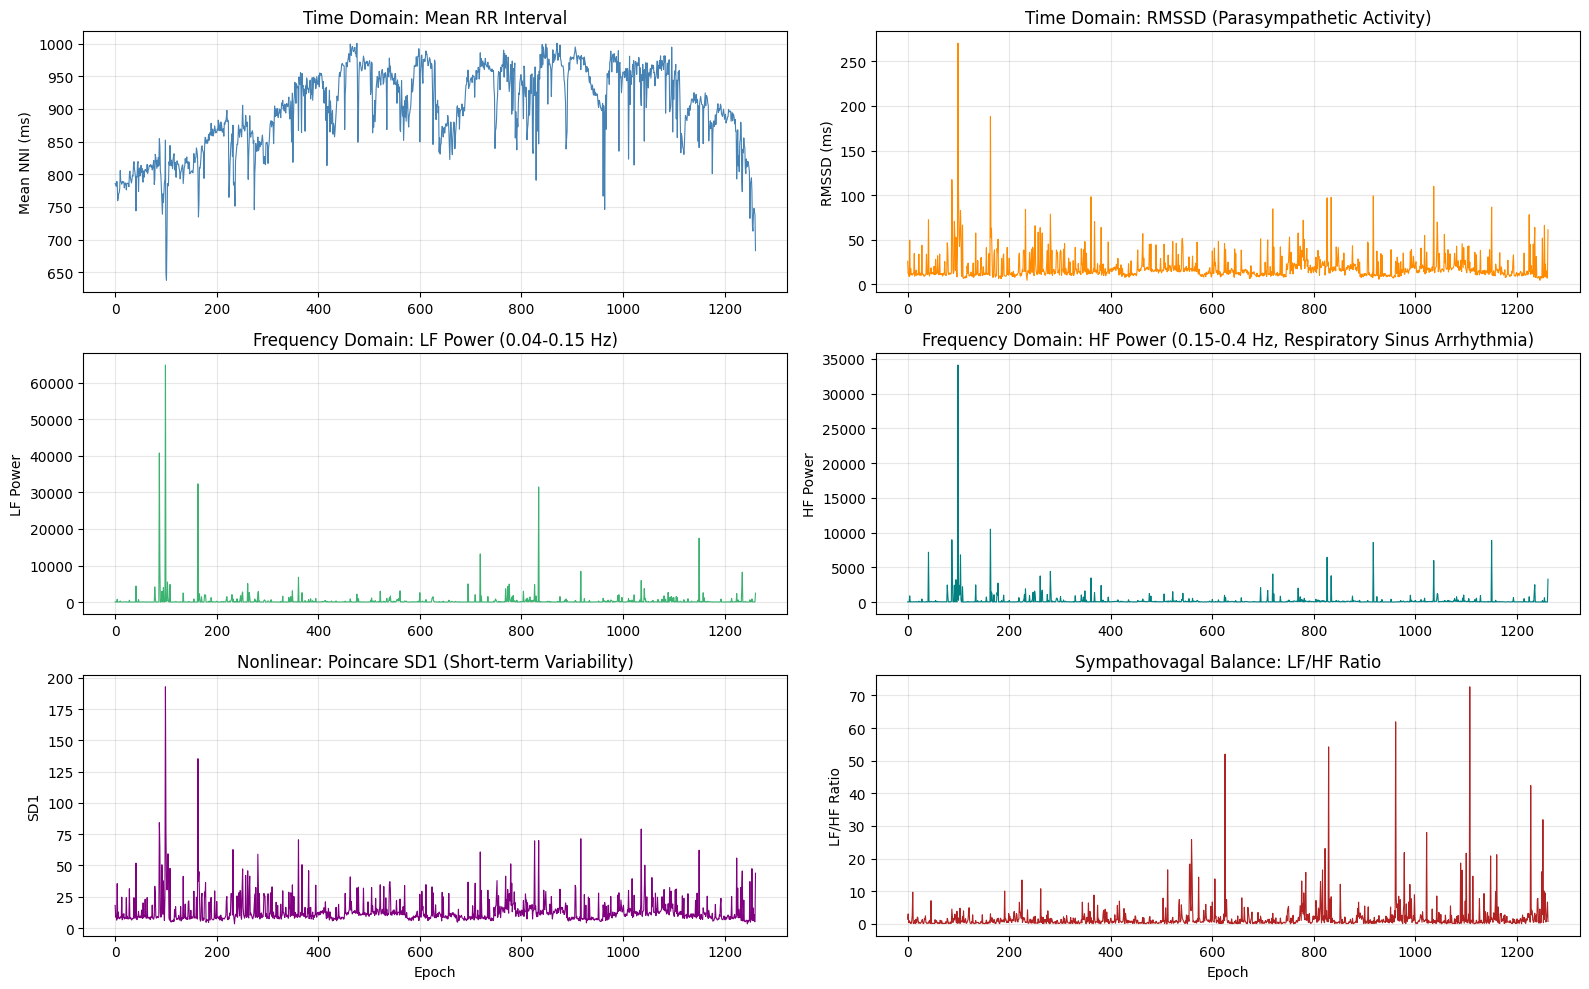

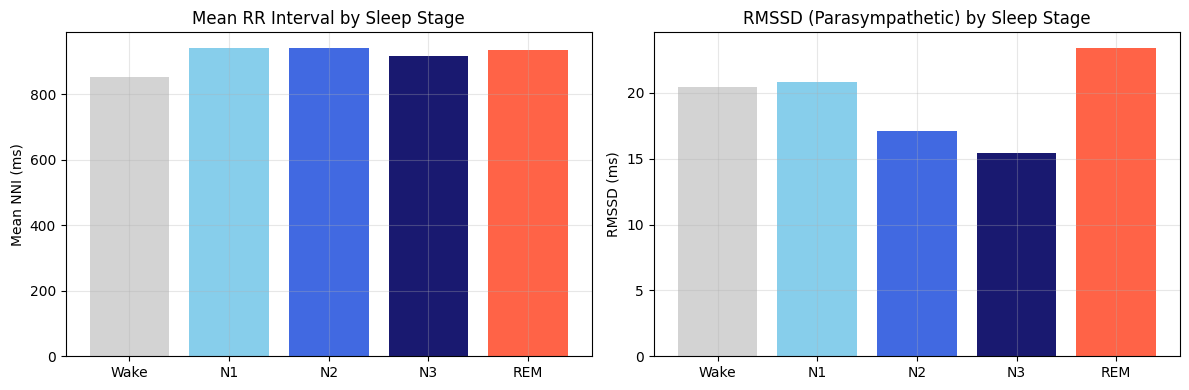

HRV 特征已保存到 /home/rdwang/repo/SleepStaging/temp/processed/hrv_features/


In [41]:
# HRV 特征可视化
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# (1) 时域: mean_nni (平均 RR 间期)
axes[0, 0].plot(hrv_features['_hrv_mean_nni'], color='steelblue', linewidth=0.8)
axes[0, 0].set_ylabel('Mean NNI (ms)')
axes[0, 0].set_title('Time Domain: Mean RR Interval', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# (2) 时域: rmssd (副交感神经活动指标)
axes[0, 1].plot(hrv_features['_hrv_rmssd'], color='darkorange', linewidth=0.8)
axes[0, 1].set_ylabel('RMSSD (ms)')
axes[0, 1].set_title('Time Domain: RMSSD (Parasympathetic Activity)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# (3) 频域: LF (低频功率)
if '_hrv_lf' in hrv_features.columns:
    axes[1, 0].plot(hrv_features['_hrv_lf'], color='mediumseagreen', linewidth=0.8)
    axes[1, 0].set_ylabel('LF Power')
    axes[1, 0].set_title('Frequency Domain: LF Power (0.04-0.15 Hz)', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

# (4) 频域: HF (高频功率 = 呼吸性窦性心律不齐)
if '_hrv_hf' in hrv_features.columns:
    axes[1, 1].plot(hrv_features['_hrv_hf'], color='teal', linewidth=0.8)
    axes[1, 1].set_ylabel('HF Power')
    axes[1, 1].set_title('Frequency Domain: HF Power (0.15-0.4 Hz, Respiratory Sinus Arrhythmia)', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

# (5) Poincare: SD1 (短时变异)
if '_hrv_sd1' in hrv_features.columns:
    axes[2, 0].plot(hrv_features['_hrv_sd1'], color='purple', linewidth=0.8)
    axes[2, 0].set_ylabel('SD1')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_title('Nonlinear: Poincare SD1 (Short-term Variability)', fontsize=12)
    axes[2, 0].grid(True, alpha=0.3)

# (6) LF/HF ratio (交感-副交感平衡)
if '_hrv_lf_hf_ratio' in hrv_features.columns:
    axes[2, 1].plot(hrv_features['_hrv_lf_hf_ratio'], color='firebrick', linewidth=0.8)
    axes[2, 1].set_ylabel('LF/HF Ratio')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_title('Sympathovagal Balance: LF/HF Ratio', fontsize=12)
    axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# HRV 随睡眠阶段的变化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# mean_nni 随睡眠阶段
stages = df_clean['5stage'].values
stage_order = [0, 1, 2, 3, 4]  # Wake, N1, N2, N3, REM
stage_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']

mean_nni_by_stage = [hrv_features['_hrv_mean_nni'][stages == s].mean() for s in stage_order]
axes[0].bar(stage_labels, mean_nni_by_stage, color=['#d3d3d3', '#87CEEB', '#4169E1', '#191970', '#FF6347'])
axes[0].set_ylabel('Mean NNI (ms)')
axes[0].set_title('Mean RR Interval by Sleep Stage')
axes[0].grid(True, alpha=0.3)

# rmssd 随睡眠阶段
rmssd_by_stage = [hrv_features['_hrv_rmssd'][stages == s].mean() for s in stage_order]
axes[1].bar(stage_labels, rmssd_by_stage, color=['#d3d3d3', '#87CEEB', '#4169E1', '#191970', '#FF6347'])
axes[1].set_ylabel('RMSSD (ms)')
axes[1].set_title('RMSSD (Parasympathetic) by Sleep Stage')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 保存
hrv_features.to_csv(OUTPUT_DIR / f'hrv_features/hrv_features{SUBJ_ID}.csv', index=False)
print(f'HRV 特征已保存到 {OUTPUT_DIR}/hrv_features/')

## Step 6: 特征合并

将四模态特征合并为统一的特征表，每个 epoch 一行，每列一个特征。

In [42]:
# ===================================================================
# Step 6: 特征合并
# ===================================================================

# 手动合并以展示过程 (也可以用 merge_features 自动合并)
# 从 PROCESSED_PATH 读取干净的呼吸和EDR特征
df_resp_clean = pd.read_csv(PROCESSED_PATH / f'respiration_features_clean/respiration_features{SUBJ_ID}.csv')
df_edr_clean = pd.read_csv(PROCESSED_PATH / f'edr_features_clean/edr_features{SUBJ_ID}.csv')

print('各模态维度:')
print(f'  ACT 体动特征:  {act_features.shape[0]} epochs × {act_features.shape[1]} features')
print(f'  HRV 心率特征:  {hrv_features.shape[0]} epochs × {hrv_features.shape[1]} features')
print(f'  RRV 呼吸特征:  {df_resp_clean.shape[0]} epochs × {df_resp_clean.shape[1]} features')
print(f'  EDR ECG呼吸:   {df_edr_clean.shape[0]} epochs × {df_edr_clean.shape[1]} features')

# 合并 (沿列方向拼接)
combined = pd.concat([
    act_features.reset_index(drop=True),
    hrv_features.reset_index(drop=True),
    df_resp_clean.reset_index(drop=True),
    df_edr_clean.reset_index(drop=True),
], axis=1)

print(f'\n合并后: {combined.shape[0]} epochs × {combined.shape[1]} features')
print(f'\n特征列名 (每模态前3列):')
print(f'  ACT: {list(act_features.columns[:3])}')
print(f'  HRV: {list(hrv_features.columns[:3])}')
print(f'  RRV: {list(df_resp_clean.columns[:3])}')
print(f'  EDR: {list(df_edr_clean.columns[:3])}')

各模态维度:
  ACT 体动特征:  1262 epochs × 370 features
  HRV 心率特征:  1262 epochs × 31 features
  RRV 呼吸特征:  1262 epochs × 60 features
  EDR ECG呼吸:   1262 epochs × 60 features

合并后: 1262 epochs × 521 features

特征列名 (每模态前3列):
  ACT: ['_acc_mean_1', '_acc_mean_centered_1', '_acc_median_1']
  HRV: ['_hrv_mean_nni', '_hrv_sdnn', '_hrv_sdsd']
  RRV: ['150_RRV_RMSSD', '150_RRV_MeanBB', '150_RRV_SDBB']
  EDR: ['150_EDR_RMSSD', '150_EDR_MeanBB', '150_EDR_SDBB']


In [43]:
# ===================================================================
# 最终特征表预览 & 统计
# ===================================================================
print('=== 最终特征表 ===')
print(f'形状: {combined.shape}')
print(f'\n前5行 × 前8列:')
display(combined.iloc[:5, :8])

print(f'\n基本统计 (前8列):')
display(combined.iloc[:, :8].describe())

# 特征缺失值检查
missing = combined.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(f'\n含缺失值的列 ({len(missing_cols)} 列):')
    for col, n in missing_cols.items():
        print(f'  {col}: {n} missing')
else:
    print('\n★ 无缺失值')

# 保存最终特征表
combined.to_csv(OUTPUT_DIR / f'features_full_combined/features_combined{SUBJ_ID}.csv')
print(f'\n最终特征表已保存到 {OUTPUT_DIR}/features_full_combined/')

=== 最终特征表 ===
形状: (1262, 521)

前5行 × 前8列:


,_acc_mean_1,_acc_mean_centered_1,_acc_median_1,_acc_median_centered_1,_acc_std_1,_acc_std_centered_1,_acc_max_1,_acc_max_centered_1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



基本统计 (前8列):


,_acc_mean_1,_acc_mean_centered_1,_acc_median_1,_acc_median_centered_1,_acc_std_1,_acc_std_centered_1,_acc_max_1,_acc_max_centered_1
count,1262.000000,1262.000000,1262.000000,1262.000000,1262.0,1262.0,1262.000000,1262.000000
mean,11.908875,11.908875,11.908875,11.908875,0.0,0.0,11.908875,11.908875
std,39.261123,39.261123,39.261123,39.261123,0.0,0.0,39.261123,39.261123
min,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
max,340.000000,340.000000,340.000000,340.000000,0.0,0.0,340.000000,340.000000



★ 无缺失值

最终特征表已保存到 /home/rdwang/repo/SleepStaging/temp/processed/features_full_combined/


## 总结

### 管线回顾

```
原始数据                       处理后数据
────────                      ──────────
EDF (ECG + Resp)  ──→ Step1+2 → respiration_features_raw, edr_respiration_features_raw
Actigraphy CSV    ──┐
R-point CSV       ──┤
PSG XML           ──┤ Step3 → actigraph_data_clean, ecg_data_clean
                   ──┤         respiration_features_clean, edr_features_clean
                   ──┘
actigraph_data    ──→ Step4 → actigraph_features (370维)
ecg_data          ──→ Step5 → hrv_features (31维)

所有特征           ──→ Step6 → features_full_combined (~460维)
```

### 每名被试的数据量

| 产出 | 大小 (约) |
|---|---|
| 原始 EDF | ~40 MB |
| 原始体动 | ~2 MB |
| 处理后全部 | ~15 MB |

### 如何换被试

回到第1节，修改 `SUBJ_ID = '0001'` 为其他编号，然后 Run All Cells。